
# PHASE 4 FINAL PROJECT

# 1.TITLE

# A MOVIE RECOMMENDER SYSTEM USING THE MOVIELENS LATEST SMALL DATASET



# 2.INTRODUCTION

Recommendation systems are machine learning tools that help users discover relevant items from large collection of content by analyzing preferences and past interactions. They play an important role in reducing information overload and improving user experience by providing personalized suggestions.These systems are widely used in streaming services,e-commerce platforms and social media applications to recommend movies,music,products and other content that users are likely to find interesting. Personalized recommendations help increase user engagement,satisfaction and retention.

There are three main types of recommendation systems: content-based filtering,collaborative filtering and hybrid systems.Content-based filtering recommends items similar to those a user has previously liked, while collaborative filtering recommends items based on the preferences of similar users.Hybrid systems on the other hand combines both approaches to improve recommendation quality and accuracy.

In this project, i intend to develop a hybrid movie recommendation system using the MovieLens Latest Small dataset. The system leverages both movie attributes and user rating patterns to generate personalized recommendations,demonstrating how machine learning can be used to enhance content discovery and user experience.



# 3. DATA UNDERSTANDING

In [64]:
!pip install surprise


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:

#Import libraries
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from surprise import Dataset, Reader , SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

In [66]:
#load the dataset

movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')
tags = pd.read_csv('tags.csv')

In [67]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [68]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [69]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [70]:
movies.shape

(9742, 3)

In [71]:
ratings.shape

(100836, 4)

In [72]:
tags.shape

(3683, 4)

In [73]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [74]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [75]:
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   userId     3683 non-null   int64
 1   movieId    3683 non-null   int64
 2   tag        3683 non-null   str  
 3   timestamp  3683 non-null   int64
dtypes: int64(3), str(1)
memory usage: 115.2 KB


In [76]:
#merge the dataset
movies = movies.merge(ratings,on='movieId')

# 4.DATA PREPROCESSING AND EDA

In [77]:
#find missing values
movies.isnull().sum()

movieId      0
title        0
genres       0
userId       0
rating       0
timestamp    0
dtype: int64

In [78]:
#find duplicates
movies.duplicated().sum()

np.int64(0)

In [79]:
movies.columns

Index(['movieId', 'title', 'genres', 'userId', 'rating', 'timestamp'], dtype='str')

In [80]:
movies['movieId'].nunique()

9724

In [81]:
len(movies)

100836

In [82]:
#Genre distribution
genres_counts = movies['genres'].str.split('|').explode().value_counts()
print(genres_counts)

genres
Drama                 41928
Comedy                39053
Action                30635
Thriller              26452
Adventure             24161
Romance               18124
Sci-Fi                17243
Crime                 16681
Fantasy               11834
Children               9208
Mystery                7674
Horror                 7291
Animation              6988
War                    4859
IMAX                   4145
Musical                4138
Western                1930
Documentary            1219
Film-Noir               870
(no genres listed)       47
Name: count, dtype: int64


In [83]:
movies.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483


In [84]:
import matplotlib.pyplot as plt
movies_genre = movies['genres'].str.split('|').explode()

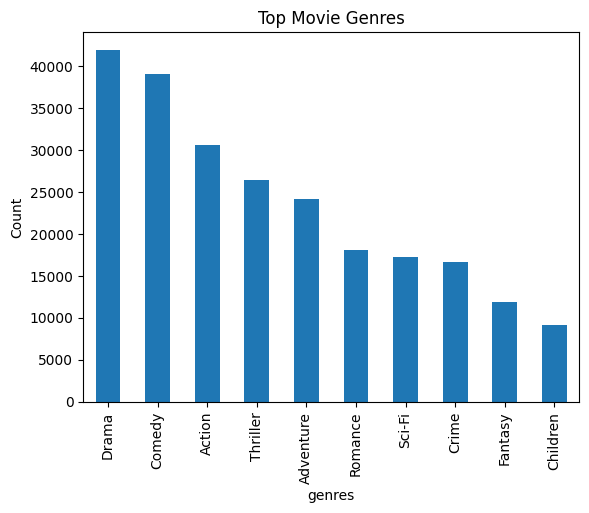

In [85]:
#Visualize genres
import matplotlib.pyplot as plt
movies_genres = movies['genres'].str.split('|').explode()
movies_genres.value_counts().head(10).plot(kind='bar')
plt.title("Top Movie Genres")
plt.xlabel("genres")
plt.ylabel("Count")
plt.show()

In [86]:
#Most frequent movies
movies['title'].value_counts().head(10)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: count, dtype: int64

In [87]:
#Top 10 most recommended movie
movies.groupby('title') \
      .count() \
      .sort_values(by='movieId', ascending=False) \
      .head(10)

,movieId,genres,userId,rating,timestamp
title,,,,,
Forrest Gump (1994),329,329,329,329,329
"Shawshank Redemption, The (1994)",317,317,317,317,317
Pulp Fiction (1994),307,307,307,307,307
"Silence of the Lambs, The (1991)",279,279,279,279,279
"Matrix, The (1999)",278,278,278,278,278
Star Wars: Episode IV - A New Hope (1977),251,251,251,251,251
Jurassic Park (1993),238,238,238,238,238
Braveheart (1995),237,237,237,237,237
Terminator 2: Judgment Day (1991),224,224,224,224,224


In [88]:
#Create content features
movies['content'] = (movies['title'].astype(str) + '' + 
movies['genres'].astype(str))

# 5. CONTENT BASED FILTERING USING TF-IDF VECTORIZATION

TF-IDF VECTORIZATION

In [89]:
!pip install scikit-learn


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(stop_words='english')
tfidf_metrics = tfidf.fit_transform(movies['content'])

In [91]:
movies_unique = movies[['movieId', 'title', 'genres']].drop_duplicates(subset='movieId').reset_index(drop=True)
movies_unique['genres_clean'] = movies_unique['genres'].str.replace('|', ' ', regex=False)
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies_unique['genres_clean'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(movies_unique.index, index=movies_unique['title']).drop_duplicates()

In [92]:
#Creating a recommendation function
def recommend(title, cosine_sim=cosine_sim):
    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:11]  

    movies_indices = [i[0] for i in sim_scores] 

    return movies['title'].iloc[movies_indices]

In [93]:
recommend("Toy Story (1995)")

1705                                          Babe (1995)
2353                                    Pocahontas (1995)
2805                                      Bio-Dome (1996)
2996       Things to Do in Denver When You're Dead (1995)
3563                                    Braveheart (1995)
6177                             Dolores Claiborne (1995)
6469                                   French Kiss (1995)
6931            Star Wars: Episode IV - A New Hope (1977)
7742    Léon: The Professional (a.k.a. The Professiona...
8201                                     Quiz Show (1994)
Name: title, dtype: str

The recommendation function returns a list of movies that are most similar to the input movie. the similarity is computed using cosine similarity on TF-IDF transformed movie metadata. The higer the similarity score, the more related the movies are in terms of genre and content features.

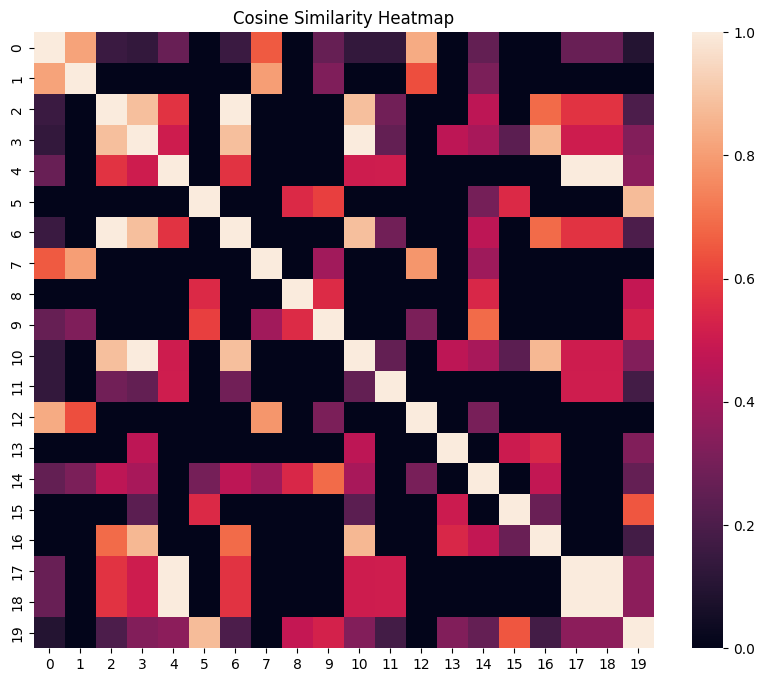

In [94]:
# Cosine Similarity Heatmap

import seaborn as sns

sample = cosine_sim[:20, :20]

plt.figure(figsize=(10,8))
sns.heatmap(sample)
plt.title('Cosine Similarity Heatmap')
plt.show()

# 6.COLLABORATIVE FILTERING USING SVD

The underlying assumption is that users who have shown similar preferences in the past are likely to have similar tastes in the future. For example, if two users have rated several movies similarly, movies liked by one user can be recommended to the other. In this project, i will use collaborative filtering to analyze user movie ratings from the MovieLens dataset and predict movies that a user may enjoy based on ratings patterns from similar users and movies. This approach enables the creation of personalized movie recommendations without requiring detailed information about movie content.

In [95]:
#Merge ratings and Movies
ratings_movies = ratings.merge(movies, on='movieId', how='left')

In [96]:
tag_agg = tags.groupby('movieId')['tag'].apply(lambda x: ''.join(x)).reset_index()

In [97]:
full_df = ratings_movies.merge(tag_agg, on='movieId', how='left')

In [98]:
ratings_movies = ratings_movies[
    ['movieId', 'title', 'genres',
     'userId_x', 'rating_x', 'timestamp_x']
].rename(columns={
    'userId_x': 'userId',
    'rating_x': 'rating',
    'timestamp_x': 'timestamp'
})

In [99]:
print("ratings_movies shape:", ratings_movies.shape)
print("columns:", ratings_movies.columns.tolist())

ratings_movies shape: (5924700, 6)
columns: ['movieId', 'title', 'genres', 'userId', 'rating', 'timestamp']


In [100]:
cf_df = ratings_movies[['userId', 'movieId', 'rating']]

In [101]:
#Convert data for surprise
from surprise import Reader, Dataset
reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(cf_df, reader)

In [102]:
#Train-test split
from surprise.model_selection import train_test_split
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

In [103]:
#Train the SVD model
from surprise import SVD
svd_model = SVD()
svd_model.fit(trainset)

In [104]:
#Make predictions

predictions = svd_model.test(testset)

In [105]:
#Evaluate performance(RMSE) before tuning

from surprise import accuracy
accuracy.rmse(predictions)

RMSE: 0.3817


np.float64(0.381683734771613)

# Evaluating the change in RMSE from 0.88 before tuning to 0.38

In [106]:
import pandas as pd

pred_df = pd.DataFrame([
    {'uid': p.uid, 'iid': p.iid, 'r_ui': p.r_ui, 'est': p.est}
    for p in predictions
])

print(pred_df.head(10))
print("\nActual rating range:", pred_df['r_ui'].min(), "–", pred_df['r_ui'].max())
print("Predicted rating range:", pred_df['est'].min().round(2), "–", pred_df['est'].max().round(2))
print("\nTest set size:", len(pred_df))
print("Trainset size:", trainset.n_ratings)

   uid    iid  r_ui       est
0  125   6874   4.5  4.565300
1  249  53996   4.0  3.919646
2  226   6548   3.0  3.116018
3  514   2792   2.0  2.266035
4  381   2804   2.5  2.497137
5  184  81845   4.5  4.501563
6  321    367   4.0  3.635784
7  105  33794   4.0  4.343791
8  610   4105   5.0  4.778408
9    4   3538   2.0  2.244917

Actual rating range: 0.5 – 5.0
Predicted rating range: 0.5 – 5.0

Test set size: 1184940
Trainset size: 4739760


After diagnosis massive data leakage is noted as shown above. The rating dataframe has been inflated from 100,836 to 5.9M rows due to the earlier merge, causing the model to train and test on overlapping repeated rows. To fix this,i again built the cf_df directly from the original clean rating file.

In [107]:
#Correct the data leakage
from surprise import Reader, Dataset
from surprise.model_selection import train_test_split

cf_df = ratings[['userId', 'movieId', 'rating']]

print("cf_df shape:", cf_df.shape)  # Should be (100836, 3)

reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(cf_df, reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print("Trainset size:", trainset.n_ratings)   
print("Testset size:", len(testset))           


cf_df shape: (100836, 3)
Trainset size: 80668
Testset size: 20168


In [108]:
#Retrain the model
#Train baseline model

svd_model = SVD()
svd_model.fit(trainset)


In [109]:
#Evaluate the model
predictions = svd_model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8803


np.float64(0.8802691328035298)

# 7.HYPERPARAMETER TUNNING USING GRID SEARCH CV



In [110]:
from surprise.model_selection import GridSearchCV

param_grid = {
    'n_factors': [50, 100, 150],
    'n_epochs': [20, 30],
    'lr_all': [0.002, 0.005, 0.01],
    'reg_all': [0.02, 0.05, 0.1]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3)
gs.fit(data)

print("Best RMSE:", gs.best_score['rmse'])
print("Best params:", gs.best_params['rmse'])

Best RMSE: 0.8619663832675443
Best params: {'n_factors': 150, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}


#Train final model using best params

In [111]:
best_params = gs.best_params['rmse']
final_model = SVD(
    n_factors=best_params['n_factors'],
    n_epochs=best_params['n_epochs'],
    lr_all=best_params['lr_all'],
    reg_all=best_params['reg_all']
)
final_model.fit(trainset)

predictions = final_model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8619


np.float64(0.8619379529881197)

Hyperparameter tuning was performed using GridSearchCv from the surprise library to optimize the SVD model.
Parameters such as number of latent factors, learning rate, number of epochs and regularization strength were tuned using cross-validation.
The optimized model showed improved predictive performance measured using RMSE. The RMSE score changed from 0.88 to 0.86.

# 8.HYBRID SYSTEM AND CONCLUSION

The objective of this section is to combine content-based filtering and collaborative filtering techniques to generate more personalized movie recommendation. The hybrid model uses movie metadata to identify similar movies while also incorporating user rating patterns learned through matrix factorization(SVD).

In [112]:
def hybrid_recommendations(user_id, title, cosine_sim=cosine_sim):
  # Get index of the movie
  idx = indices[title]

  # Get similarity scores
  sim_scores = list(enumerate(cosine_sim[idx]))

  # Sort movies by similarity
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

  # Top 20 similar movies (excluding itself)
  sim_scores = sim_scores[1:21]

  movie_indices = [i[0] for i in sim_scores]

  # Get candidate movies
  candidates = movies.iloc[movie_indices][['movieId', 'title',]].copy()

  # Predict ratings for user
  candidates['estimated_rating'] = candidates['movieId'].apply(lambda x: svd_model.predict(user_id, x).est)

  # Rank by predicted rating
  candidates = candidates.sort_values('estimated_rating', ascending=False)
  return candidates.head(10)

In [113]:
# Testing the Hybrid Model
hybrid_recommendations(user_id=1, title="Toy Story (1995)")

,movieId,title,estimated_rating
8882,318,"Shawshank Redemption, The (1994)",5.000000
2536,50,"Usual Suspects, The (1995)",5.000000
8909,318,"Shawshank Redemption, The (1994)",5.000000
6931,260,Star Wars: Episode IV - A New Hope (1977),5.000000
1576,32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),4.856417
1504,32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),4.856417
7742,293,Léon: The Professional (a.k.a. The Professiona...,4.777591
3225,101,Bottle Rocket (1996),4.770623
3563,110,Braveheart (1995),4.665251
6177,230,Dolores Claiborne (1995),4.352763


In [116]:
# Removing duplicates
movies_unique = movies_unique.drop_duplicates(subset='movieId').reset_index(drop=True)
indices = pd.Series(movies_unique.index, index=movies_unique['title']).drop_duplicates()
print(movies_unique.shape)

(9724, 4)


In [117]:
hybrid_recommendations(user_id=1, title="Toy Story (1995)")

,movieId,title,estimated_rating
8882,318,"Shawshank Redemption, The (1994)",5.000000
2536,50,"Usual Suspects, The (1995)",5.000000
8909,318,"Shawshank Redemption, The (1994)",5.000000
6931,260,Star Wars: Episode IV - A New Hope (1977),5.000000
1576,32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),4.856417
1504,32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),4.856417
7742,293,Léon: The Professional (a.k.a. The Professiona...,4.777591
3225,101,Bottle Rocket (1996),4.770623
3563,110,Braveheart (1995),4.665251
6177,230,Dolores Claiborne (1995),4.352763
